<a href="https://colab.research.google.com/github/RichaGaharwar/Exploratory-Data-Analysis-Netflix-/blob/main/Netflix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---


# **About NETFLIX**


---



Netflix is one of the most popular media and video streaming platforms. They have over 10000 movies or tv shows available on their platform, as of mid-2021, they have over 222M Subscribers globally. This tabular dataset consists of listings of all the movies and tv shows available on Netflix, along with details such as - cast, directors, ratings, release year, duration, etc.


---



**Business Problem**


---



Analyze the data and generate insights that could help Netflix in deciding which type of shows/movies to produce and how they can grow the business in different countries



---




**Dataset**

---

The dataset provided to you consists of a list of all the TV shows/movies available on Netflix:

---

*   Show_id: Unique ID for every Movie / Tv Show
*   Type: Identifier - A Movie or TV Show
*   Title: Title of the Movie / Tv Show
*   Director: Director of the Movie
*   Cast: Actors involved in the movie/show
*   Country: Country where the movie/show was produced
*   Date_added: Date it was added on Netflix
*   Release_year: Actual Release year of the movie/show
*   Rating: TV Rating of the movie/show
*   Duration: Total Duration - in minutes or number of seasons
*   Listed_in: Genre
*   Description: The summary description

---

**Hints**

---

1. The exploration should have a goal. As you explore the data, keep in mind
that you want to answer which type of shows to produce and how to grow the business.

2. Ensure each recommendation is backed by data. The company is looking for data-driven insights, not personal opinions or anecdotes.

3. Assume that you are presenting your findings to business executives who have only a basic understanding of data science. Avoid unnecessary technical jargon.

4. Start by exploring a few questions:

* What type of content is available in different countries?
* How has the number of movies released per year changed over the last 20-30 years?
* Comparison of tv shows vs. movies.
* What is the best time to launch a TV show?
* Analysis of actors/directors of different types of shows/movies.
* Does Netflix has more focus on TV Shows than movies in recent years
* Understanding what content is available in different countries

---


**Evaluation Criteria**

---


1. Defining Problem Statement and Analysing basic metrics

2. Observations on the shape of data, data types of all the attributes, conversion of categorical attributes to 'category'
(If required), missing value detection, statistical summary

3. Non-Graphical Analysis: Value counts and unique attributes

4. Visual Analysis - Univariate, Bivariate after pre-processing of the data

Note: Pre-processing involves unnesting of the data in columns like Actor, Director, Country

* For continuous variable(s): Distplot, countplot, histogram for univariate analysis

* For categorical variable(s): Boxplot

5. Missing Value & Outlier check (Treatment optional)

6. Insights based on Non-Graphical and Visual Analysis

* Comments on the range of attributes

* Comments on the distribution of the variables and relationship between them

* Comments for each univariate and bivariate plot

7. Business Insights - Should include patterns observed in the data along with what you can infer from it

8. Recommendations - Actionable items for business. No technical jargon. No complications.

---



# **Importing necessary libraries and dataset first**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

netflix = pd.read_csv('/content/netflix_titles.csv')
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# **Exploratory Data Analysis**

Let's know what kind of information & how much of data we have:

In [3]:
netflix.shape

(8807, 12)

In [4]:
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


we have 12 different features:


---


**Columns and Data Types:**

---
*   Most (11/12) columns are of object dtype, which typically means that we are dealing with Categorical data ie., to generate insights that could help Netflix in deciding which type of shows/movies to produce and how they can grow the business in different countries we need to find how each of the features are  corelated to each other.


*   1 column "Date_added" needs to be converted to datetime datatype.




---
 **Non-Null Counts (Missing Values):**

---

*   Director: 2634 missing values.
*   Country: 831 missing values.
*   cast: 825 missing values.
*   date_added: 10 missing values.
*   rating: 4 missing values.
*   duration: 3 missing values.
---
**Key Takeaways:**

---
*   The dataset is relatively clean, there are still missing values in director, country cast, date_added, rating, and duration columns that might need further attention depending on the analysis.

*   The date_added column is in a numerical format, which needs to be converted into datetime format

` 825 missing values in the 'cast' column, 2634 missing values in 'director' column, 831 missing values in 'country' column are crucial for a recommendation system. Here's why:`

**Impact on Feature Engineering:**

In a recommendation system, information like 'cast', 'director', 'country' are often used as a feature to help the system understand the content.

For example:
if a user likes movie with a particular actor, the system can recommend other movies starring that actor.

**Reduced Recommendation Quality:**

A recommendation model trained on data with significant missing values will likely provide less accurate or less personalized recommendations for the affected titles.

It won't be able to leverage the information to find similarities or user preferences related to actors, directors or country.

**Bias in Recommendations:**

If the missing values are not random, the recommendation system might develop a bias, under-representing or mis-recommending those titles.

**Data Imputation Challenges:**

While one could try to impute (fill in) these missing values, accurately predicting the cast, director or country of a movie or TV show without any initial information is very difficult and could introduce noise or incorrect information into the dataset.


---


In essence, for a recommendation system that relies on content features, 825 missing 'cast',  2634 missing 'director' or 831 missing 'country' entries represent a significant loss of valuable information that can directly hinder the system's ability to learn and suggest relevant content.

**Changing datatype of date_added to datetime**

In [5]:
netflix['date_added'] = netflix['date_added'].astype('datetime64[ns]')
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


## **Handling Missing Values**

To ensure data completeness and avoid issues in further analysis, I'll fill the missing values in the 'director', 'cast' and 'country' columns with 'Unknown'.

In [6]:
netflix['director'].fillna('unknown', inplace=True)
netflix['country'].fillna('unknown', inplace=True)
netflix['cast'].fillna('unknown', inplace=True)
netflix['duration'].fillna('unknown', inplace=True)
netflix['rating'].fillna('unknown', inplace=True)
netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


/tmp/ipykernel_13466/2835728166.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  netflix['director'].fillna('unknown', inplace=True)
/tmp/ipykernel_13466/2835728166.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

we have filled all the missing values with unknown except 'date_added'which has 10 missing values

# **Data Preprocessing:**





unnesting director column

In [7]:
netflix2 = netflix.copy()

In [8]:
netflix['director'].value_counts().tail(8)

,count
director,
Paul Dano,1
"Frank Capra, Anatole Litvak",1
Dhruv Dhawan,1
"Milla Harrison-Hansley, Alicky Sussman",1
Drew Stone,1
Benjamin Turner,1
S. Shankar,1
Peter Hewitt,1


In [9]:
netflix2 = netflix2.assign(director = netflix2['director'].str.split(',')).explode('director')
netflix2['director'] = netflix2['director'].str.strip()
print(f"Unique directors: {netflix2['director'].nunique()}")

Unique directors: 4994


In [10]:
netflix2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9612 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       9612 non-null   object        
 1   type          9612 non-null   object        
 2   title         9612 non-null   object        
 3   director      9612 non-null   object        
 4   cast          9612 non-null   object        
 5   country       9612 non-null   object        
 6   date_added    9602 non-null   datetime64[ns]
 7   release_year  9612 non-null   int64         
 8   rating        9612 non-null   object        
 9   duration      9612 non-null   object        
 10  listed_in     9612 non-null   object        
 11  description   9612 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 976.2+ KB


Unnesting country column

In [11]:
netflix['country'].value_counts().tail(10)

,count
country,
"United States, Venezuela",1
"Germany, United States, Italy",1
"United Kingdom, Australia, Canada, United States",1
"New Zealand, United Kingdom, Australia",1
"Ireland, Canada, United States, United Kingdom",1
"Germany, Canada, United States",1
"Denmark, United Kingdom, South Africa, Sweden, Belgium",1
"Serbia, South Korea, Slovenia",1
"United Kingdom, Spain, Belgium",1


In [12]:
netflix['country'].nunique()

749

In [13]:
netflix2 = netflix2.assign(country = netflix2['country'].str.split(',')).explode('country')
netflix2['country'] = netflix2['country'].str.strip()
print(f"Unique countries: {netflix2['country'].nunique()}")

Unique countries: 124


In [14]:
netflix2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11917 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       11917 non-null  object        
 1   type          11917 non-null  object        
 2   title         11917 non-null  object        
 3   director      11917 non-null  object        
 4   cast          11917 non-null  object        
 5   country       11917 non-null  object        
 6   date_added    11907 non-null  datetime64[ns]
 7   release_year  11917 non-null  int64         
 8   rating        11917 non-null  object        
 9   duration      11917 non-null  object        
 10  listed_in     11917 non-null  object        
 11  description   11917 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 1.2+ MB


In [15]:
netflix2.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,unknown,unknown,unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


unnesting cast column

In [16]:
netflix['cast'].value_counts().tail(10)

,count
cast,
"Chutimon Chuengcharoensukying, Sutthirak Subvijitra, Nutthasit Kotimanuswanich, Sita Maharavidejakorn, Sutthatip Wutichaipradit, Warisara Yu, Chokchai Charoensuk, Supoj Pongpancharoen, Nikorn Sae Tang, Gandhi Wasuwitchayagit, Petchpatchara Kitkrairaj, Duangjai Hirunsri, Nilacha Fuangfukiet, Teeranai Na Nongk้hai, Sumontha Suanpolrat, Wimolphan Chaleejunghan, Damkerng Thitapiyasak, Natthawara Hongsuwan, Nunthapak Chalermpuwadej, Tachatorn Supanan",1
Roberto Palazuelos,1
"Michael Peña, Diego Luna, Tenoch Huerta, Joaquin Cosio, José María Yazpik, Matt Letscher, Alyssa Diaz",1
"Nick Lachey, Vanessa Lachey",1
"Takeru Sato, Kasumi Arimura, Haru, Kentaro Sakaguchi, Takayuki Yamada, Kendo Kobayashi, Ken Yasuda, Arata Furuta, Suzuki Matsuo, Koichi Yamadera, Arata Iura, Chikako Kaku, Kotaro Yoshida",1
"Toyin Abraham, Sambasa Nzeribe, Chioma Chukwuka Akpotha, Chioma Omeruah, Chiwetalu Agu, Dele Odule, Femi Adebayo, Bayray McNwizu, Biodun Stephen",1
"Neeraj Kabi, Geetanjali Kulkarni, Danish Husain, Sheeba Chaddha, Paras Priyadarshan, Anshul Chauhan, Anud Singh Dhaka, Shirin Sewani, Mihir Ahuja, Vasundhara Rajput",1
"Sanjay Dutt, Arjun Kapoor, Kriti Sanon, Zeenat Aman, Mohnish Bahl, Padmini Kolhapure, Kunal Kapoor, Suhasini Mulay",1
"Lika Berning, Bobby van Jaarsveld, Marlee van der Merwe, Sonja Herholdt, Elize Cawood, Rouel Beukes, Kevin Leo, Paul du Toit, Sylvaine Strike",1


In [17]:
netflix2 = netflix2.assign(cast = netflix2['cast'].str.split(',')).explode('cast')
netflix2['cast'] = netflix2['cast'].str.strip()
print(f"Unique casts: {netflix2['cast'].nunique()}")

Unique casts: 36440


In [18]:
netflix2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89415 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       89415 non-null  object        
 1   type          89415 non-null  object        
 2   title         89415 non-null  object        
 3   director      89415 non-null  object        
 4   cast          89415 non-null  object        
 5   country       89415 non-null  object        
 6   date_added    89346 non-null  datetime64[ns]
 7   release_year  89415 non-null  int64         
 8   rating        89415 non-null  object        
 9   duration      89415 non-null  object        
 10  listed_in     89415 non-null  object        
 11  description   89415 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 8.9+ MB


In [19]:
netflix2.shape

(89415, 12)

We now have 10 times more data as we did before

# **Analysis Movie vs TV show**

In [20]:
netflix2['type'].value_counts()

,count
type,
Movie,65379
TV Show,24036


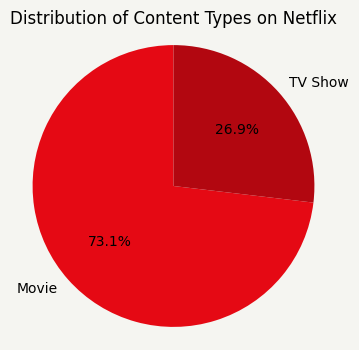

In [21]:
content_type_counts = netflix2['type'].value_counts()
plt.figure(figsize = (4,4), facecolor='#f5f5f1')
plt.pie(content_type_counts, labels = content_type_counts.index, autopct= "%1.1f%%", startangle = 90, colors = ['#E50914', '#B20710'])
plt.title("Distribution of Content Types on Netflix")
plt.axis("equal")
plt.show()

From the output, we can see that out of 8807 records the dataset contains:

 **6131 Movies &
2676 TV Shows**

# **movies VS TV Shows [different genres]**

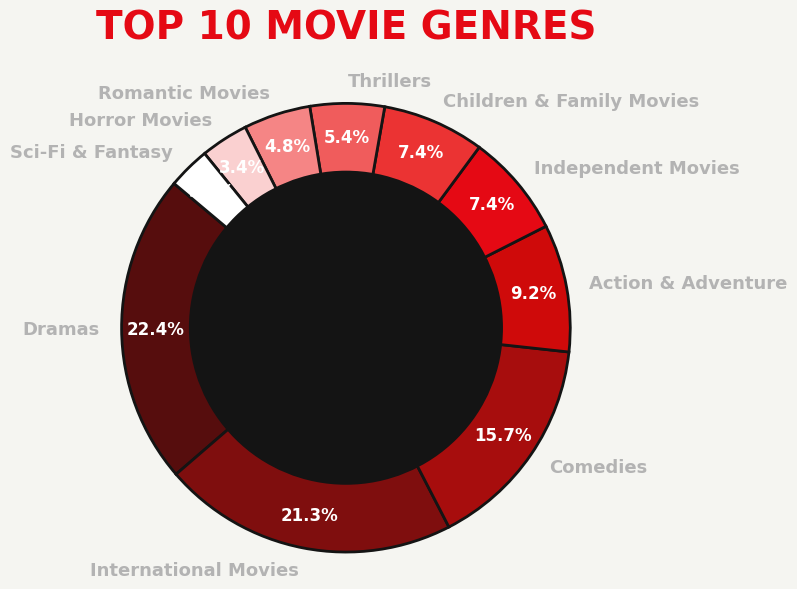

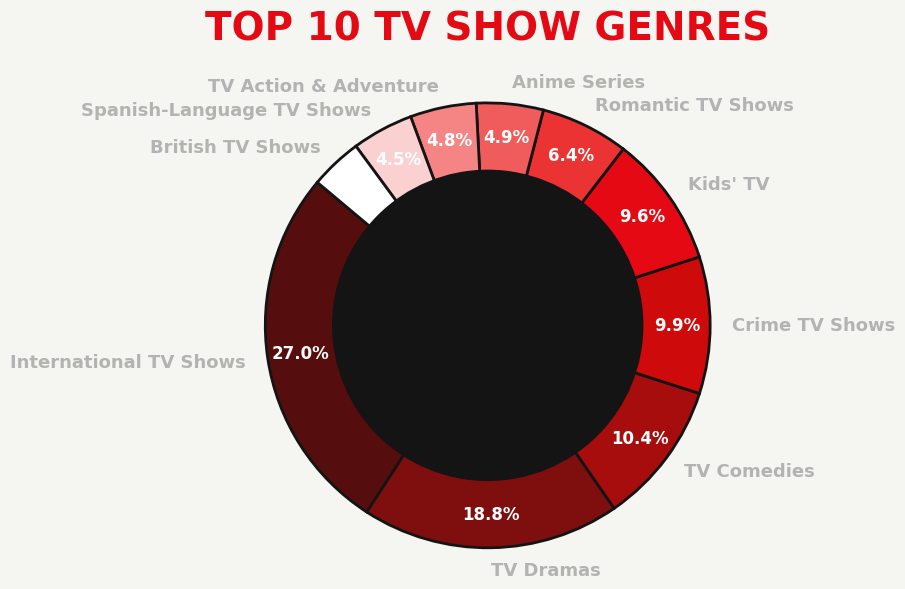

In [23]:
def plot_netflix_theme_pie(dataframe, title_type, filename):
    # Data Preparation
    subset = dataframe[dataframe['type'] == title_type]
    genres = subset['listed_in'].str.split(', ').explode()
    counts = genres.value_counts().head(10)

    colors = ['#560d0d', '#7f0e0e', '#a70d0d', '#cf0a0a', '#e50914',
              '#eb3333', '#f05c5c', '#f58585', '#fad0d0', '#ffffff']


    background_color = '#141414'
    fig = plt.figure(figsize=(8, 6), facecolor='#f5f5f1')
    ax = fig.add_subplot(111)
    ax.set_facecolor(background_color)

    wedges, texts, autotexts = ax.pie(
        counts,
        labels=counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        pctdistance=0.85,
        wedgeprops={'edgecolor': background_color, 'linewidth': 2},
        textprops={'color': 'white', 'fontsize': 12, 'fontweight': 'bold'}
    )


    for text in texts:
        text.set_color('#b3b3b3')
        text.set_fontsize(13)


    plt.title(f'TOP 10 {title_type.upper()} GENRES',
              fontsize=28,
              fontweight='black',
              color='#E50914',
              pad=30,
              fontname='sans-serif')

    centre_circle = plt.Circle((0,0), 0.70, fc=background_color)
    fig.gca().add_artist(centre_circle)

    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(filename, facecolor=background_color, dpi=300)
    plt.show()

# Generate Netflix-themed charts
plot_netflix_theme_pie(netflix2, 'Movie', 'netflix_movies.png')
plot_netflix_theme_pie(netflix2, 'TV Show', 'netflix_tv_shows.png')

# **Top 3 movie genres (almost 60%) are:**

*   **International movies**
*   **Drama**
*   **Comedy**



# **Top 3 TV Show genres (about 50%) are:**

*   **International TV Shows**
*   **Drama**
*   **Comedy**

# **Movies VS TV [different countries]**

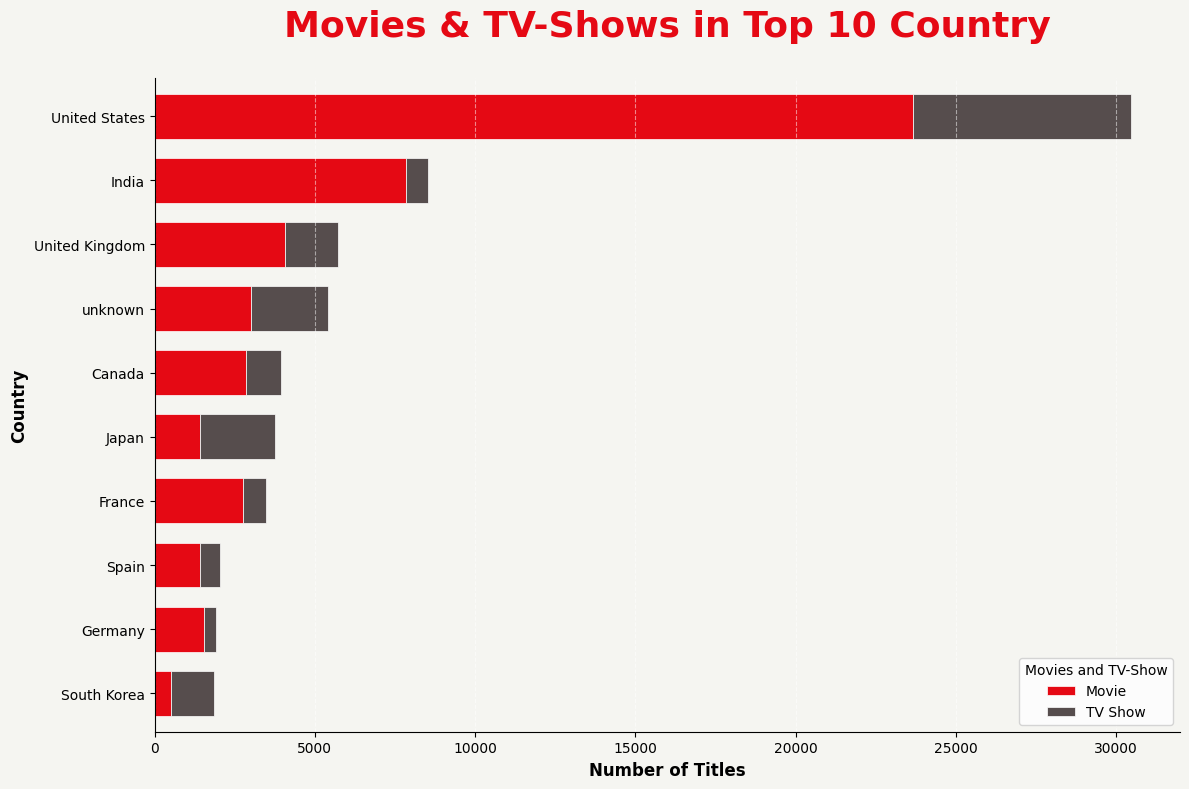

In [24]:
top_countries = netflix2['country'].value_counts().head(10).index
df_top = netflix2[netflix2['country'].isin(top_countries)]

country_content = df_top.groupby(['country', 'type']).size().unstack(fill_value=0)

country_content['Total'] = country_content.sum(axis=1)
country_content = country_content.sort_values('Total', ascending=True).drop('Total', axis=1)

Netflix_Red = '#E50914'
Dark_Grey = '#564d4d'
BG_Grey = '#d3d3d3'

fig, ax = plt.subplots(figsize=(12, 8), facecolor='#f5f5f1')
ax.set_facecolor('#f5f5f1')

country_content.plot(kind='barh',
                     stacked=True,
                     color=[Netflix_Red, Dark_Grey],
                     ax=ax,
                     width=0.7,
                     edgecolor='white',
                     linewidth=0.5)

plt.title('Movies & TV-Shows in Top 10 Country',
          fontsize=26, fontweight='black', color=Netflix_Red, pad=30)

plt.xlabel('Number of Titles', fontsize=12, fontweight='bold', color='black')
plt.ylabel('Country', fontsize=12, fontweight='bold', color='black')

plt.legend(title='Movies and TV-Show', frameon=True, facecolor='white', loc='lower right')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='white')

plt.tight_layout()
plt.show()

# **Pattern of Movie released in last 20-30 years**

In [25]:
movie_released = netflix2[netflix2['type']=='Movie']['release_year'].value_counts().sort_index().tail(30)
movie_released

,count
release_year,
1992,234
1993,354
1994,206
1995,246
1996,216
1997,476
1998,391
1999,421
2000,575


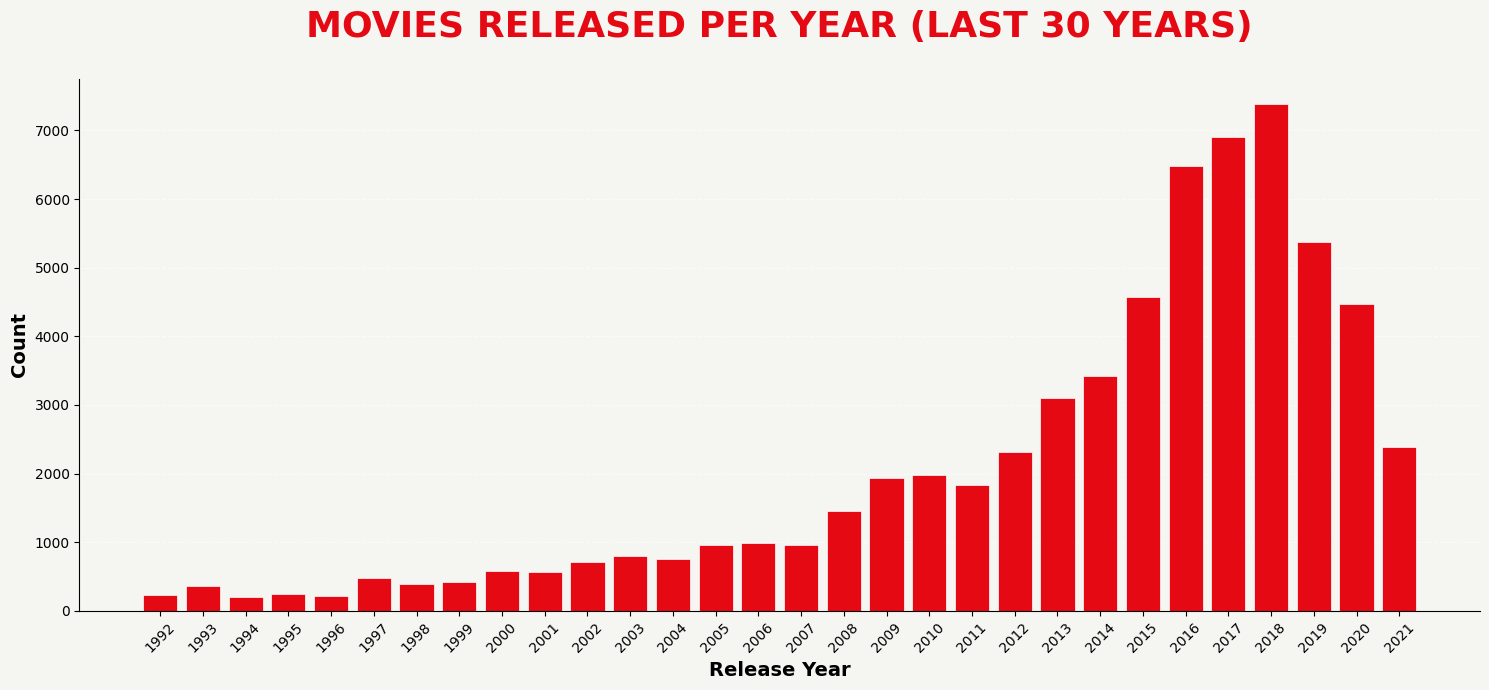

In [28]:
bg_color = '#f5f5f1'
netflix_red = '#E50914'
text_color = 'black'

fig, ax = plt.subplots(figsize=(15, 7))
fig.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

bars = ax.bar(movie_released.index, movie_released.values,
              color=netflix_red, edgecolor='white', linewidth=0.5)

plt.title('MOVIES RELEASED PER YEAR (LAST 30 YEARS)',
          fontsize=26, fontweight='black', color=netflix_red, pad=30)

plt.xlabel('Release Year', fontsize=14, fontweight='bold', color=text_color)
plt.ylabel('Count', fontsize=14, fontweight='bold', color=text_color)

plt.xticks(movie_released.index, rotation=45, color=text_color)
plt.yticks(color=text_color)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='white')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# **Pattern of TV Shows released in last 20-30 years**

In [26]:
TV_Show_released = netflix2[netflix2['type']=='TV Show']['release_year'].value_counts().sort_index().tail(30)
TV_Show_released

,count
release_year,
1992,21
1993,40
1994,8
1995,28
1996,61
1997,125
1998,62
1999,138
2000,54


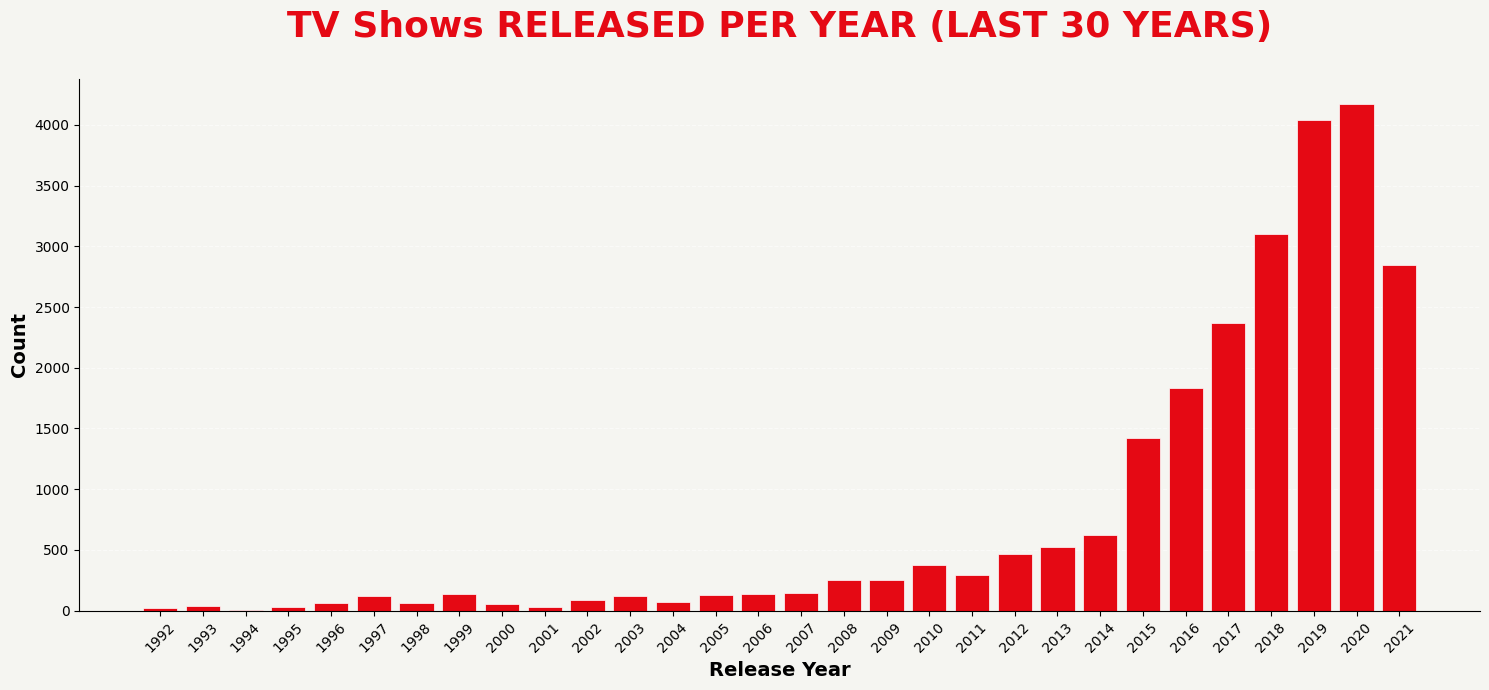

In [27]:
bg_color = '#f5f5f1'
netflix_red = '#E50914'
text_color = 'black'

fig, ax = plt.subplots(figsize=(15, 7))
fig.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

bars = ax.bar(TV_Show_released.index, TV_Show_released.values,
              color=netflix_red, edgecolor='white', linewidth=0.5)

plt.title('TV Shows RELEASED PER YEAR (LAST 30 YEARS)',
          fontsize=26, fontweight='black', color=netflix_red, pad=30)

plt.xlabel('Release Year', fontsize=14, fontweight='bold', color=text_color)
plt.ylabel('Count', fontsize=14, fontweight='bold', color=text_color)

plt.xticks(TV_Show_released.index, rotation=45, color=text_color)
plt.yticks(color=text_color)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='white')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# **Comparison of Movies vs TV Shows**

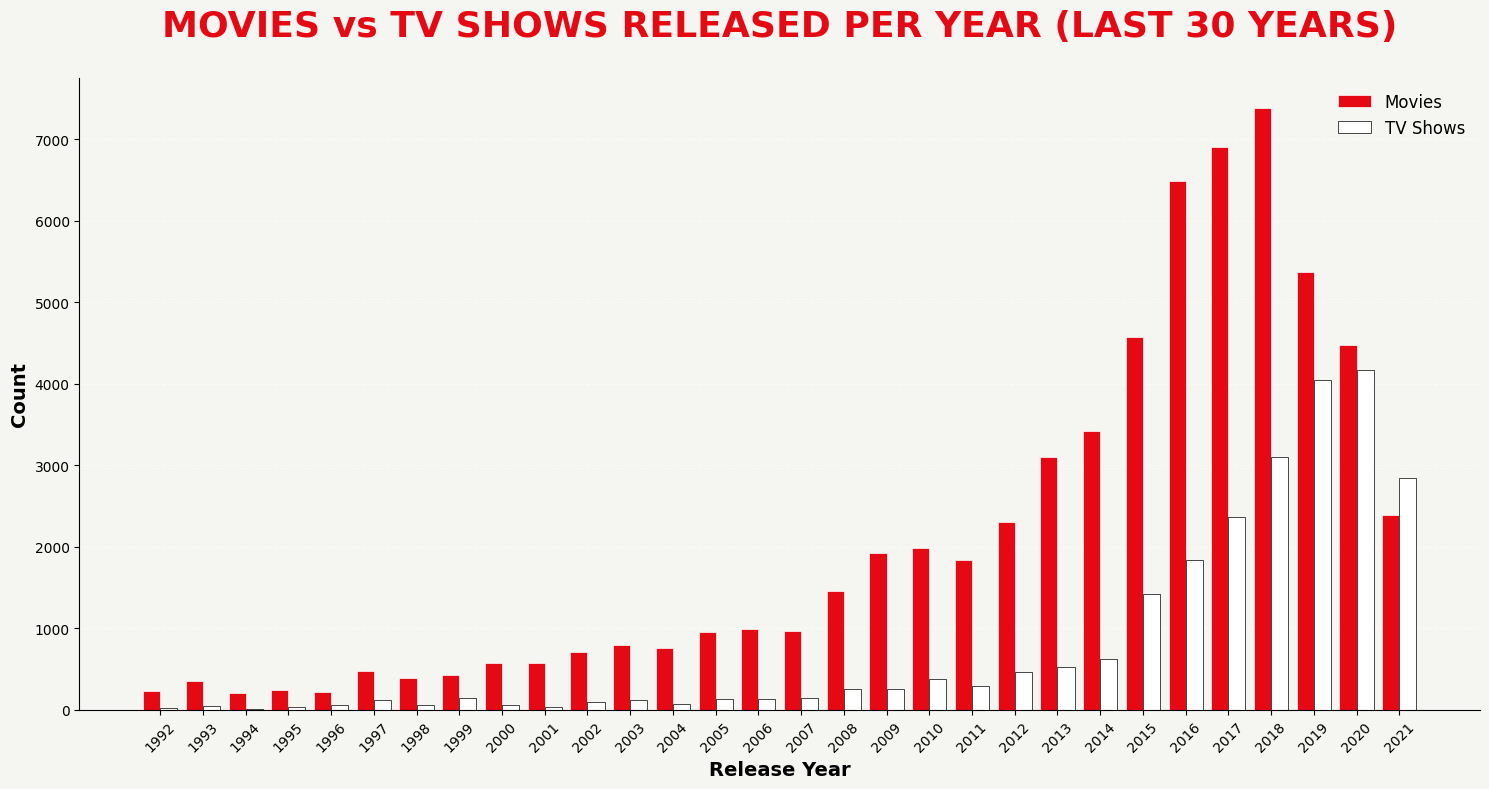

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Styling constants
bg_color = '#f5f5f1'
netflix_red = '#E50914'
text_color = 'black'

# Setup the figure
fig, ax = plt.subplots(figsize=(15, 8))
fig.set_facecolor(bg_color)
ax.set_facecolor(bg_color)

# Chart parameters
width = 0.4  # Width of each bar
x = np.arange(len(movie_released.index))  # Label locations

# Plotting the bars side-by-side
bars1 = ax.bar(x - width/2, movie_released.values, width,
               color=netflix_red, edgecolor='white', linewidth=0.5, label='Movies')

bars2 = ax.bar(x + width/2, TV_Show_released.values, width,
               color='white', edgecolor='black', linewidth=0.5, label='TV Shows')

# Title and Labels
plt.title('MOVIES vs TV SHOWS RELEASED PER YEAR (LAST 30 YEARS)',
          fontsize=26, fontweight='black', color=netflix_red, pad=30)

plt.xlabel('Release Year', fontsize=14, fontweight='bold', color=text_color)
plt.ylabel('Count', fontsize=14, fontweight='bold', color=text_color)

# X and Y axis formatting
plt.xticks(x, movie_released.index, rotation=45, color=text_color)
plt.yticks(color=text_color)

# Remove chart borders (spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid and Legend
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='white')
ax.set_axisbelow(True)
plt.legend(frameon=False, fontsize=12)

plt.tight_layout()
plt.show()

# **Best time to launch a TV show**

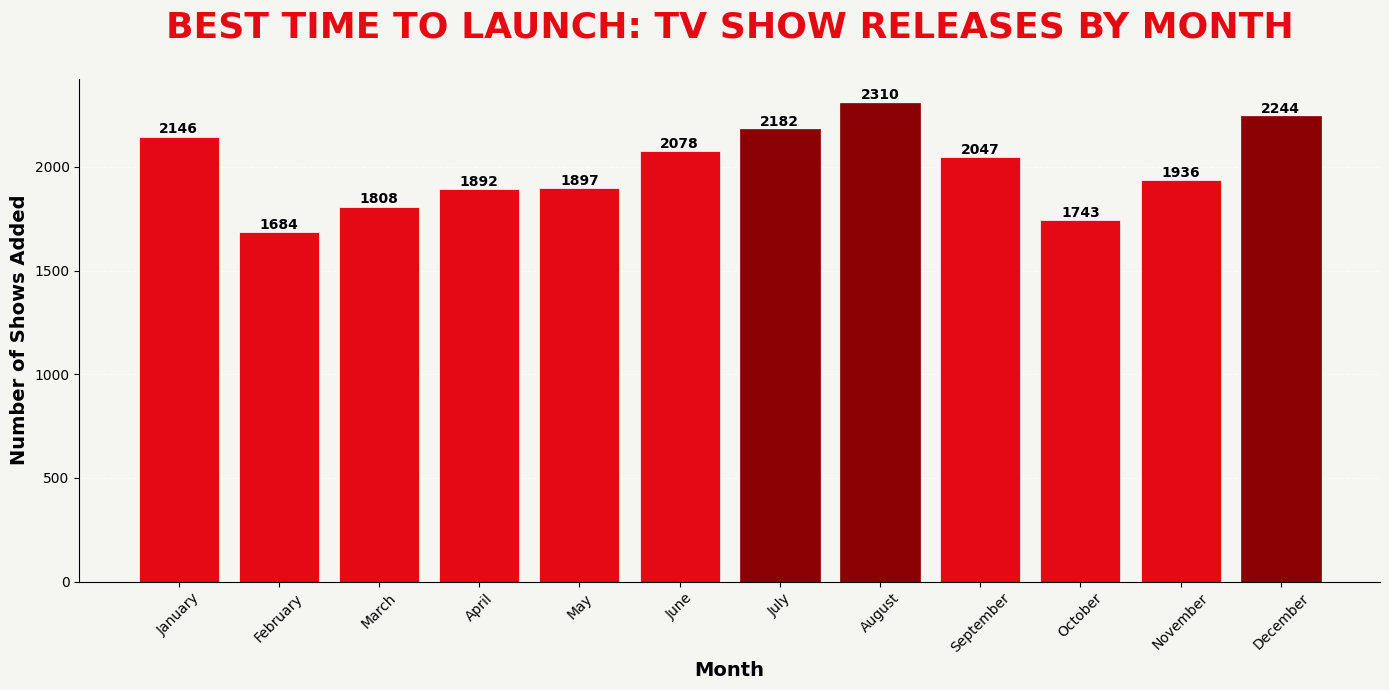

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare the Data
# Convert date_added to datetime and extract the month name
netflix2['date_added'] = pd.to_datetime(netflix2['date_added'], format='%B %d, %Y', errors='coerce')
tv_shows = netflix2[netflix2['type'] == 'TV Show']
month_counts = tv_shows['date_added'].dt.month_name().value_counts()

# Ensure the months are in chronological order
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_counts = month_counts.reindex(month_order)

# 2. Styling Constants
Netflix_Red = '#E50914'
BG_Grey = '#f5f5f1'
Text_Black = 'black'
Peak_Red = '#8B0000' # Deep red for the peak months

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(14, 7), facecolor=BG_Grey)
ax.set_facecolor(BG_Grey)

# Create the Bar Chart
bars = ax.bar(month_counts.index, month_counts.values,
              color=Netflix_Red, edgecolor='white', linewidth=0.5)

# Highlight the Peak Month (usually December)
top_3_indices = np.argsort(month_counts.values)[-3:]
for idx in top_3_indices:
    bars[idx].set_color(Peak_Red)

# 4. Final Formatting
plt.title('BEST TIME TO LAUNCH: TV SHOW RELEASES BY MONTH',
          fontsize=26, fontweight='black', color=Netflix_Red, pad=30)

plt.xlabel('Month', fontsize=14, fontweight='bold', color=Text_Black)
plt.ylabel('Number of Shows Added', fontsize=14, fontweight='bold', color=Text_Black)

plt.xticks(rotation=45, color=Text_Black)
plt.yticks(color=Text_Black)

# Remove top/right borders and add grid
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='white')
ax.set_axisbelow(True)

# Add data labels above bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{int(height)}', ha='center', va='bottom', color=Text_Black, fontweight='bold')

plt.tight_layout()
plt.show()

# **Analysis on directors**

In [39]:
netflix2['director'].nunique()

4994

In [40]:
netflix2['director'].value_counts().head(10)

,count
director,
unknown,21937
Martin Scorsese,217
Steven Spielberg,205
Martin Campbell,154
Raja Gosnell,154
McG,150
Youssef Chahine,150
Rajiv Chilaka,139
Don Michael Paul,132


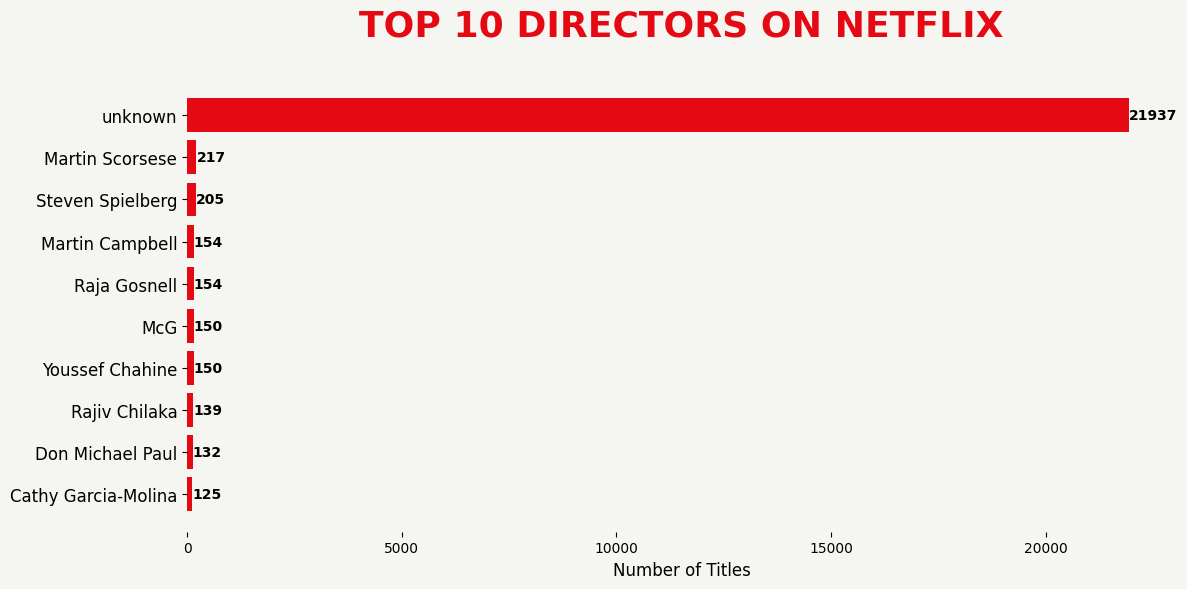

In [41]:
top_10_directors = netflix2['director'].value_counts().head(10)

bg_color = '#141414'
netflix_red = '#E50914'

fig, ax = plt.subplots(figsize=(12, 6), facecolor='#f5f5f1')
ax.set_facecolor('#f5f5f1')

bars = ax.barh(top_10_directors.index, top_10_directors.values, color=netflix_red)
ax.invert_yaxis()

plt.title('TOP 10 DIRECTORS ON NETFLIX',
          fontsize=26, fontweight='black', color=netflix_red, pad=30)

plt.xlabel('Number of Titles', color='black', fontsize=12)
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black', labelsize=12)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height()/2,
            f'{int(width)}', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

**Martin Scorsese** and **Steven Spielberg** are the most prolific directors, with 217 and 205 titles respectively. Other notable directors in the top 10 include **Martin Campbell**, **Raja Gosnell**, and **McG**.

In [ ]:
titles_per_director = netflix2[netflix2['director'] != 'unknown'].groupby('director')['show_id'].nunique()
average_titles_per_director = titles_per_director.mean()
print(f"The average number of titles per director (excluding 'unknown') is: {average_titles_per_director:.2f}")

# **Analysis on countries**

In [ ]:
# Get the top 10 countries by content count
top_10_countries = netflix['country'].value_counts().head(10)
display(top_10_countries)

In [ ]:
top_10_countries = netflix2['country'].value_counts().head(10)

bg_color = '#141414'
netflix_red = '#E50914'

fig, ax = plt.subplots(figsize=(12, 6), facecolor='#f5f5f1')
ax.set_facecolor('#f5f5f1')
bars = ax.barh(top_10_countries.index, top_10_countries.values, color=netflix_red)
ax.invert_yaxis()

plt.title('TOP 10 COUNTRIES ON NETFLIX',
          fontsize=26, fontweight='black', color=netflix_red, pad=30)

plt.xlabel('Number of Titles', color='black', fontsize=12)
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black', labelsize=12)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(False)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height()/2,
            f'{int(width)}', va='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

The **United States** has a significantly higher number of titles [2818]. Countries like **India**, the **United Kingdom**, and **Japan** also contribute a substantial amount of content

# **Type & Rating of content**

In [ ]:
movie_ratings = netflix2[netflix2['type']=='Movie']['rating'].value_counts()

In [ ]:
netflix_red = '#E50914'
netflix_dark = '#221F1F'

custom_palette = sns.blend_palette([netflix_dark, netflix_red], n_colors=10)
custom_palette = list(reversed(custom_palette))

plt.figure(figsize=(12, 8), facecolor='#f5f5f1')
ax = sns.barplot(
    x = movie_ratings.index,
    y = movie_ratings.values,
    palette= custom_palette,
    hue = movie_ratings.index,
    legend=False
)

plt.title('Movies produced of different ratings on Netflix',fontsize=16, fontweight='bold', pad=20)
plt.xlabel('ratings')
plt.ylabel('Number of movies')
plt.xticks(rotation=35, ha='right')

for i in ax.containers:
  ax.bar_label(i, padding = 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
TVShow_ratings = netflix2[netflix2['type']=='TV Show']['rating'].value_counts()

In [ ]:
netflix_red = '#E50914'
netflix_dark = '#221F1F'

custom_palette = sns.blend_palette([netflix_dark, netflix_red], n_colors=10)
custom_palette = list(reversed(custom_palette))

plt.figure(figsize=(10, 8), facecolor='#f5f5f1')
ax = sns.barplot(
    x = TVShow_ratings.index,
    y = TVShow_ratings.values,
    palette= custom_palette,
    hue = TVShow_ratings.index,
    legend=False
)

plt.title('TV Shows produced of different ratings on Netflix',fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ratings')
plt.ylabel('Number of TV Shows')
plt.xticks(rotation=35, ha='right')

for i in ax.containers:
  ax.bar_label(i, padding = 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Analysis on duration**

In [ ]:
netflix2['duration'].value_counts()

In [ ]:
movies = netflix2[netflix2['type']=='Movie'].copy()
movies['duration_num'] = movies['duration'].str.extract('(\d+)').astype(float)

In [ ]:
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Statistics
mean = movies['duration_num'].mean()
std_dev = movies['duration_num'].std()
n = len(movies['duration_num'])

# Calculate 1 SD bounds
sd_low, sd_high = mean - std_dev, mean + std_dev

# Calculate 95% CI bounds
ci = st.t.interval(confidence=0.95, df=n-1, loc=mean, scale=st.sem(movies['duration_num']))
ci_low, ci_high = ci

# 2. Setup Plot with Netflix Theme
bg_grey = '#d3d3d3' # Grey background
netflix_red = '#E50914'

plt.figure(figsize=(12, 8), facecolor='#f5f5f1')
ax = plt.gca()
ax.set_facecolor('#f5f5f1')

# Histogram
sns.histplot(movies['duration_num'], bins=40, kde=True, color=netflix_red,
             alpha=0.8, edgecolor='white', linewidth=0.5)

# 3. Add Statistical Layers
# Mean Line
plt.axvline(mean, color='black', linestyle='-', linewidth=2.5, label=f'Mean: {mean:.1f} min')

# Shaded Area for 1 Standard Deviation (Spread of Data)
plt.axvspan(sd_low, sd_high, color='black', alpha=0.1, label='1 Std Dev Range')


# Labels & Styling
plt.title('DISTRIBUTION OF MOVIE DURATIONS',
          fontsize=22, fontweight='black', color=netflix_red, pad=20)
plt.xlabel('Duration (in minutes)', fontsize=14, color='black', fontweight='bold')
plt.ylabel('Count', fontsize=14, color='black', fontweight='bold')
plt.tick_params(colors='black')
plt.legend(facecolor='white', framealpha=0.9)

plt.tight_layout()
plt.show()

The movie library on Netflix is heavily standardized, with a clear preference for content in the 90–110 minute range. While the platform supports a wide variety of lengths, the distribution follows a near-normal curve, suggesting that streaming consumption habits still align closely with traditional cinema timing.

In [ ]:
TV_shows = netflix2[netflix2['type']=='TV Show'].copy()
TVShow_durations = TV_shows['duration'].value_counts()
TVShow_durations

In [ ]:
netflix_red = '#E50914'
netflix_dark = '#221F1F'

custom_palette = sns.blend_palette([netflix_dark, netflix_red], n_colors=10)
custom_palette = list(reversed(custom_palette))

plt.figure(figsize=(12, 8), facecolor='#f5f5f1')
ax = sns.barplot(
    x = TVShow_durations.index,
    y = TVShow_durations.values,
    palette= custom_palette,
    hue = TVShow_durations.index,
    legend=False
)

plt.title('TV Shows produced of different durations on Netflix',fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Durations')
plt.ylabel('Number of TV Shows')
plt.xticks(rotation=35, ha='right')

for i in ax.containers:
  ax.bar_label(i, padding = 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
recent_movie = movies[movies['release_year']>=2010]
yearly_avg = recent_movie.groupby('release_year')['duration_num'].mean()

plt.figure(figsize=(12,8), facecolor='#f5f5f1')
sns.lineplot(x = yearly_avg.index, y = yearly_avg.values, marker='o' , color = 'red')
plt.title('Average Movie Duration Over Time')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (in minutes)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

Regarding release_year, the key insights are:

Netflix shows a strong focus on recent productions, with the years 2018, 2017, and 2019 having the most prolific content releases.
The platform has a diverse library that also includes older titles, some dating back to 1925 and 1947.
There was a peak in content production around 2018-2019, which could indicate a period of aggressive content acquisition or production by Netflix.

In [ ]:
netflix2[netflix2['type']=='Movie']['listed_in'].value_counts()

In [ ]:
netflix2[netflix2['type']=='TV Show']['listed_in'].value_counts()

# **analysis  **

In [ ]:
netflix_red = '#E50914'
netflix_dark = '#221F1F'

custom_palette = sns.blend_palette([netflix_dark, netflix_red], n_colors=10)
custom_palette = list(reversed(custom_palette))

plt.figure(figsize=(12, 8), facecolor='#f5f5f1')
ax = sns.barplot(
    x = top_10_countries.index,
    y = top_10_countries.values,
    palette= custom_palette,
    hue = top_10_countries.index,
    legend=False
)

plt.title('Top 10 Countries by Content Count on Netflix',fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=35, ha='right')

for i in ax.containers:
  ax.bar_label(i, padding = 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


The output shows the top 10 countries by content count on Netflix:


*   **United States** leads significantly with **2818 titles**.
*   **India** is second with **972 titles**.
*   The **'Unknown'** category, which was used to fill missing values, accounts for **831 titles**, indicating a substantial number of entries where the country of origin was not specified.
*   The **United Kingdom** follows with **419 titles**.
*   Other countries in the **top 10 include Japan, South Korea, Canada, Spain, France,** and **Mexico**.










In [ ]:
netflix2['release_year'].nunique()

74 years of data

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

netflix_red = '#E50914'
netflix_dark = '#221F1F'
cmap_colors = [netflix_dark, netflix_red]
n_bin = 25
netflix_cmap = LinearSegmentedColormap.from_list("netflix_red_fade", cmap_colors, N=n_bin)

plt.figure(figsize=(12, 6), facecolor='#f5f5f1')

ax = sns.histplot(netflix['release_year'], bins=n_bin, color=netflix_red, edgecolor=netflix_dark)
patches = ax.patches

N_bars = len(patches)
norm = mcolors.Normalize(0, N_bars - 1)

for i, patch in enumerate(patches):
    color = netflix_cmap(norm(i))
    patch.set_facecolor(color)

# 5. Styling
plt.title('Distribution of Content Release Years on Netflix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Release Years', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Insights from `release_year`:

*   Netflix has a significant amount of newer content, with the years 2018, 2017, and 2019 being the most prolific. This suggests a focus on recent productions.
*   While there's a strong presence of recent releases, the dataset also includes older titles, with some dating back to 1925 and 1947, indicating a diverse library that spans many decades.
*   The peak in content production seems to be around 2018-2019, potentially reflecting a period of aggressive content acquisition or production by Netflix.

In [ ]:
netflix2['rating'].value_counts()

### Insights from `rating`:

*   **Dominant Ratings:** The most common ratings are `TV-MA` (3207 titles), `TV-14` (2160 titles), and `TV-PG` (863 titles), indicating a significant amount of content aimed at mature or teenage audiences.
*   **Movie Ratings:** Ratings like `R`, `PG-13`, `PG`, `G`, and `NC-17` are also present, reflecting the diverse movie library.
*   **TV Show Ratings:** Ratings like `TV-Y7`, `TV-Y`, `TV-G`, and `TV-Y7-FV` are specific to TV shows and indicate content suitable for younger viewers.
*   **Anomalies:** There are a few entries like '74 min', '84 min', and '66 min' which appear to be durations rather than ratings. These are likely data entry errors and would need to be cleaned if a detailed analysis of ratings is required.

In [ ]:
netflix2.head()